# Bước 2 – Data Collection, Understanding & Preparation
## Olist Brazilian E-Commerce · Reverse Logistics Analysis

**Mục tiêu của bước này:**
1. Đọc & hiểu cấu trúc 8 bảng nguồn trong folder datasets
2. Kiểm tra chất lượng dữ liệu (missing, duplicate, referential integrity)
3. Chuẩn hoá kiểu dữ liệu & chuỗi ký tự
4. Phát hiện và xử lý **Outliers**
5. Feature engineering
6. Xuất **một file CSV tổng hợp duy nhất** (`olist_analytical_table.csv`) cho các bước 3 → 6


## 0. Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

print("Import thư viện thành công!")

Import thư viện thành công!


## 1. Đọc dữ liệu (Data Loading)

In [2]:
DATA_DIR = "datasets/"

df_orders            = pd.read_csv(DATA_DIR + "olist_orders_dataset.csv")
df_order_items       = pd.read_csv(DATA_DIR + "olist_order_items_dataset.csv")
df_order_reviews     = pd.read_csv(DATA_DIR + "olist_order_reviews_dataset.csv")
df_order_payments    = pd.read_csv(DATA_DIR + "olist_order_payments_dataset.csv")
df_customers         = pd.read_csv(DATA_DIR + "olist_customers_dataset.csv")
df_products          = pd.read_csv(DATA_DIR + "olist_products_dataset.csv")
df_sellers           = pd.read_csv(DATA_DIR + "olist_sellers_dataset.csv")
df_category_trans    = pd.read_csv(DATA_DIR + "product_category_name_translation.csv")

datasets = {
    "orders": df_orders, "order_items": df_order_items,
    "order_reviews": df_order_reviews, "order_payments": df_order_payments,
    "customers": df_customers, "products": df_products,
    "sellers": df_sellers, "category_translation": df_category_trans,
}

print("Đọc dữ liệu thành công!\n")
summary = pd.DataFrame([(k, v.shape[0], v.shape[1]) for k,v in datasets.items()],
                       columns=["Bảng","Số dòng","Số cột"])
summary["Số dòng"] = summary["Số dòng"].map("{:,}".format)
display(summary.set_index("Bảng"))

Đọc dữ liệu thành công!



,Số dòng,Số cột
Bảng,,
orders,"99,441",8
order_items,"112,650",7
order_reviews,"99,224",7
order_payments,"103,886",5
customers,"99,441",5
products,"32,951",9
sellers,"3,095",4
category_translation,71,2


## 2. Hiểu cấu trúc dữ liệu (Data Understanding)

### Lược đồ quan hệ

```
customers ──< orders ──< order_items >── products >── category_translation
                  │            │
                  │            └──< sellers
                  ├──< order_reviews
                  └──< order_payments
```

| Bảng trái | Khoá | Bảng phải |
|-----------|------|-----------|
| orders | `customer_id` | customers |
| order_items | `order_id` | orders |
| order_reviews | `order_id` | orders |
| order_payments | `order_id` | orders |
| order_items | `product_id` | products |
| order_items | `seller_id` | sellers |
| products | `product_category_name` | category_translation |

In [3]:
for name, df in datasets.items():
    print(f"{'─'*55}")
    print(f"Bảng {name}  ({df.shape[0]:,} rows × {df.shape[1]} cols)")
    display(df.head(2))

───────────────────────────────────────────────────────
Bảng orders  (99,441 rows × 8 cols)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00


───────────────────────────────────────────────────────
Bảng order_items  (112,650 rows × 7 cols)


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93


───────────────────────────────────────────────────────
Bảng order_reviews  (99,224 rows × 7 cols)


...

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.00,287.00,1.00,225.00,16.00,10.00,14.00
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.00,276.00,1.00,"1,000.00",30.00,18.00,20.00


───────────────────────────────────────────────────────
Bảng sellers  (3,095 rows × 4 cols)


,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP


───────────────────────────────────────────────────────
Bảng category_translation  (71 rows × 2 cols)


,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories


## 3. Kiểm tra chất lượng dữ liệu (Data Quality Check)

### 3.1 Missing Values

In [4]:
def missing_report(df, name):
    miss  = df.isnull().sum()
    pct   = (miss / len(df) * 100).round(2)
    result = pd.DataFrame({"Missing": miss, "Pct (%)": pct})
    result = result[result["Missing"] > 0].sort_values("Pct (%)", ascending=False)
    if result.empty:
        print(f" [{name}] Không có missing values")
    else:
        print(f" [{name}] Có missing values!")
        display(result)

print("=" * 55)
for name, df in datasets.items():
    missing_report(df, name)
    print()

 [orders] Có missing values!


,Missing,Pct (%)
order_delivered_customer_date,2965,2.98
order_delivered_carrier_date,1783,1.79
order_approved_at,160,0.16



 [order_items] Không có missing values

 [order_reviews] Có missing values!


,Missing,Pct (%)
review_comment_title,87656,88.34
review_comment_message,58247,58.70



 [order_payments] Không có missing values

 [customers] Không có missing values

 [products] Có missing values!


,Missing,Pct (%)
product_category_name,610,1.85
product_name_lenght,610,1.85
product_description_lenght,610,1.85
product_photos_qty,610,1.85
product_weight_g,2,0.01
product_length_cm,2,0.01
product_height_cm,2,0.01
product_width_cm,2,0.01



 [sellers] Không có missing values

 [category_translation] Không có missing values



### 3.2 Duplicate Values

In [5]:
dup_cfg = {
    "orders"          : ["order_id"],
    "order_items"     : ["order_id","order_item_id"],
    "order_reviews"   : ["review_id"],
    "order_payments"  : ["order_id","payment_sequential"],
    "customers"       : ["customer_id"],
    "products"        : ["product_id"],
    "sellers"         : ["seller_id"],
    "category_translation": ["product_category_name"],
}
rows = []
for name, df in datasets.items():
    pk_cols = dup_cfg[name]
    rows.append({
        "Bảng"          : name,
        "Trùng toàn dòng": df.duplicated().sum(),
        f"Trùng PK {pk_cols}" : df.duplicated(subset=pk_cols).sum(),
    })
display(pd.DataFrame(rows).set_index("Bảng"))

,Trùng toàn dòng,Trùng PK ['order_id'],"Trùng PK ['order_id', 'order_item_id']",Trùng PK ['review_id'],"Trùng PK ['order_id', 'payment_sequential']",Trùng PK ['customer_id'],Trùng PK ['product_id'],Trùng PK ['seller_id'],Trùng PK ['product_category_name']
Bảng,,,,,,,,,
orders,0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
order_items,0,NaN,0.00,NaN,NaN,NaN,NaN,NaN,NaN
order_reviews,0,NaN,NaN,814.00,NaN,NaN,NaN,NaN,NaN
order_payments,0,NaN,NaN,NaN,0.00,NaN,NaN,NaN,NaN
customers,0,NaN,NaN,NaN,NaN,0.00,NaN,NaN,NaN
products,0,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN
sellers,0,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN
category_translation,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00


### 3.3 Referential Integrity (Join Key)

In [6]:
def check_integrity(l_df, l_key, r_df, r_key, label):
    l_keys = set(l_df[l_key].dropna())
    r_keys = set(r_df[r_key].dropna())
    orphan  = len(l_keys - r_keys)
    print(f"  🔗 {label}")
    print(f"     Unique left={len(l_keys):,}  |  right={len(r_keys):,}  |  "
          f"orphan (left∉right)={orphan}")

print("Kiểm tra referential integrity:")
check_integrity(df_orders,       "customer_id", df_customers, "customer_id",   "orders → customers")
check_integrity(df_order_items,  "order_id",    df_orders,    "order_id",      "order_items → orders")
check_integrity(df_order_reviews,"order_id",    df_orders,    "order_id",      "order_reviews → orders")
check_integrity(df_order_payments,"order_id",   df_orders,    "order_id",      "order_payments → orders")
check_integrity(df_order_items,  "product_id",  df_products,  "product_id",    "order_items → products")
check_integrity(df_order_items,  "seller_id",   df_sellers,   "seller_id",     "order_items → sellers")

Kiểm tra referential integrity:
  🔗 orders → customers
     Unique left=99,441  |  right=99,441  |  orphan (left∉right)=0
  🔗 order_items → orders
     Unique left=98,666  |  right=99,441  |  orphan (left∉right)=0
  🔗 order_reviews → orders
     Unique left=98,673  |  right=99,441  |  orphan (left∉right)=0
  🔗 order_payments → orders
     Unique left=99,440  |  right=99,441  |  orphan (left∉right)=0
  🔗 order_items → products
     Unique left=32,951  |  right=32,951  |  orphan (left∉right)=0
  🔗 order_items → sellers
     Unique left=3,095  |  right=3,095  |  orphan (left∉right)=0


## 4. Chuẩn hoá dữ liệu (Preprocessing)

### 4.1 Chuyển đổi kiểu dữ liệu

In [7]:
# ── Datetime ──────────────────────────────────────────────────────────
dt_order_cols = [
    "order_purchase_timestamp","order_approved_at",
    "order_delivered_carrier_date","order_delivered_customer_date",
    "order_estimated_delivery_date",
]
for col in dt_order_cols:
    df_orders[col] = pd.to_datetime(df_orders[col], errors="coerce")

df_order_items["shipping_limit_date"]          = pd.to_datetime(df_order_items["shipping_limit_date"],          errors="coerce")
df_order_reviews["review_creation_date"]       = pd.to_datetime(df_order_reviews["review_creation_date"],       errors="coerce")
df_order_reviews["review_answer_timestamp"]    = pd.to_datetime(df_order_reviews["review_answer_timestamp"],    errors="coerce")

print("Datetime OK")
print(df_orders[dt_order_cols].dtypes)

Datetime OK
order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


### 4.2 Chuẩn hoá chuỗi (String Normalization)

In [8]:
df_orders["order_status"]                       = df_orders["order_status"].str.lower().str.strip()
df_order_payments["payment_type"]               = df_order_payments["payment_type"].str.lower().str.strip()
df_customers["customer_state"]                  = df_customers["customer_state"].str.upper().str.strip()
df_customers["customer_city"]                   = df_customers["customer_city"].str.lower().str.strip()
df_sellers["seller_state"]                      = df_sellers["seller_state"].str.upper().str.strip()
df_sellers["seller_city"]                       = df_sellers["seller_city"].str.lower().str.strip()
df_products["product_category_name"]            = df_products["product_category_name"].str.lower().str.strip()
df_category_trans["product_category_name"]      = df_category_trans["product_category_name"].str.lower().str.strip()
df_category_trans["product_category_name_english"] = df_category_trans["product_category_name_english"].str.lower().str.strip()

print("String normalization OK")
print("\norder_status distribution:")
print(df_orders["order_status"].value_counts())

String normalization OK

order_status distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


### 4.3 Xử lý Missing Values

In [9]:
# Products: điền trung vị cho cột số
num_prod_cols = ["product_name_lenght","product_description_lenght","product_photos_qty",
                 "product_weight_g","product_length_cm","product_height_cm","product_width_cm"]
for col in num_prod_cols:
    med = df_products[col].median()
    df_products[col].fillna(med, inplace=True)

# Products: category thiếu → 'unknown'
df_products["product_category_name"].fillna("unknown", inplace=True)

# Reviews: text columns → chuỗi rỗng (không bắt buộc điền)
df_order_reviews["review_comment_title"].fillna("",   inplace=True)
df_order_reviews["review_comment_message"].fillna("", inplace=True)

# Orders: timestamp thiếu không xoá — sẽ phát sinh NaN ở feature sau, xử lý ở join
print("Missing values đã xử lý")
print("\nKiểm tra lại products:")
print(df_products[num_prod_cols].isnull().sum())

Missing values đã xử lý

Kiểm tra lại products:
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_length_cm             0
product_height_cm             0
product_width_cm              0
dtype: int64


## 5. Phát hiện và xử lý Outliers

**Chiến lược:** Dùng **Winsorization (Capping)** thay vì xoá dòng.  
- Giữ nguyên số dòng → không mất thông tin đơn hàng  
- Cap tại ngưỡng **1st – 99th percentile** cho từng cột số quan trọng  
- Ghi lại flag `is_outlier_*` để các bước phân tích sau có thể lọc nếu cần

>  Không áp dụng IQR (1.5×IQR) ở đây vì tỉ lệ outlier lên tới ~10% — quá lớn để xoá.  
> Dữ liệu thương mại thực tế luôn có giá trị cực biên hợp lệ (hàng xa xỉ, hàng cồng kềnh, v.v.).

### 5.1 Visualize phân phối trước khi xử lý

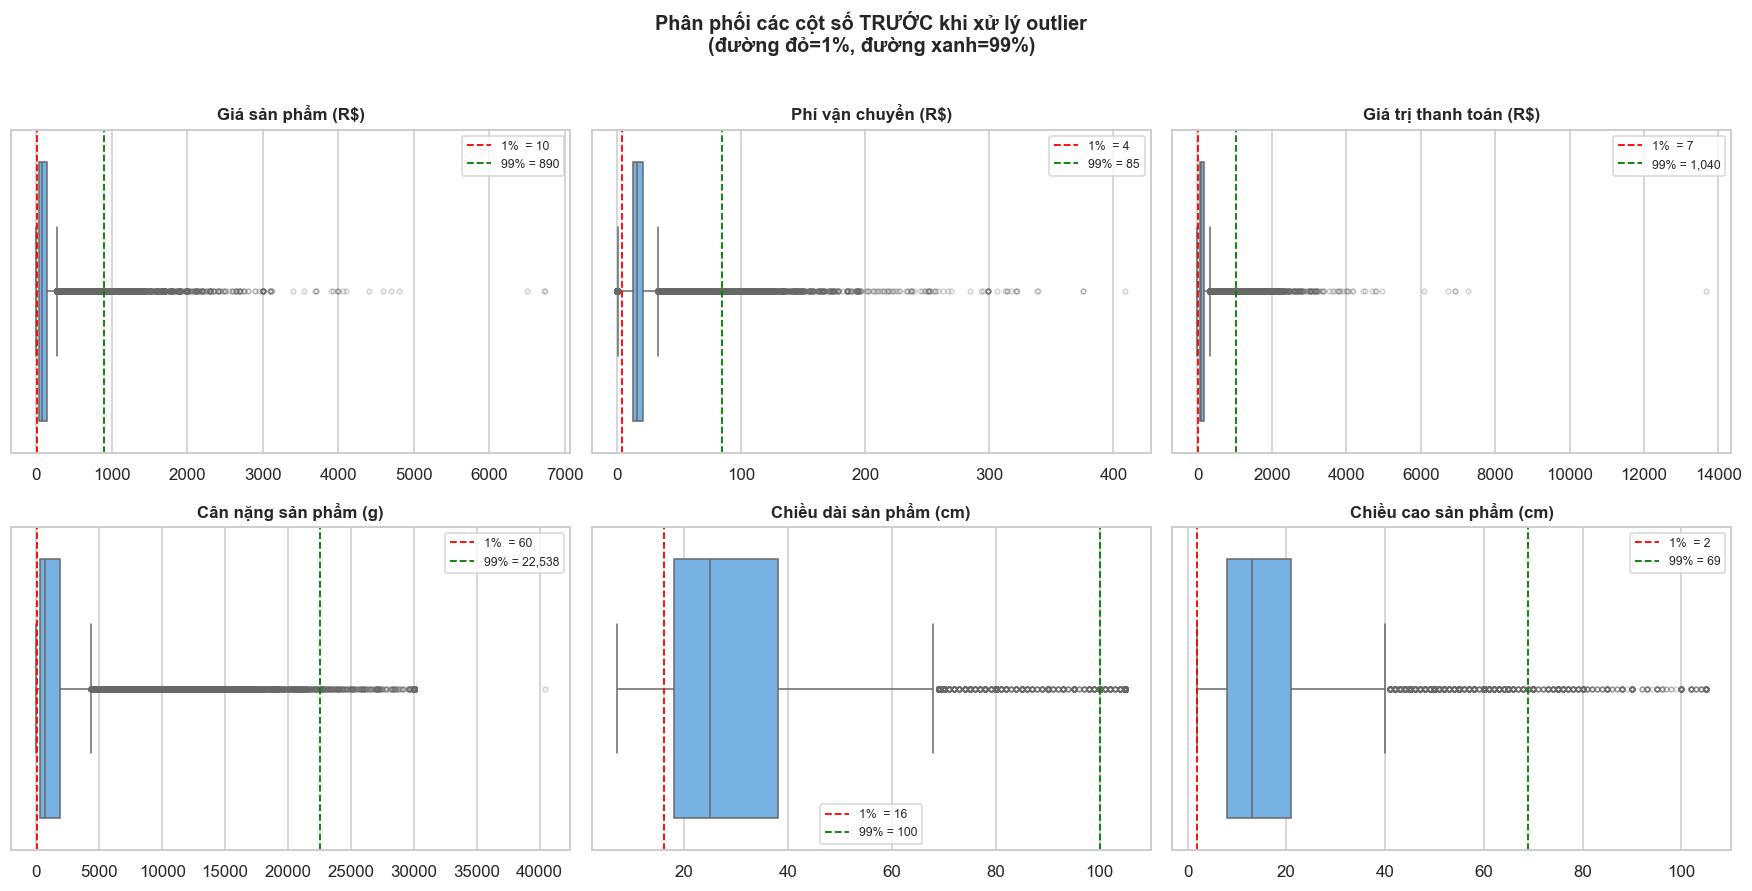

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

plot_configs = [
    (df_order_items,  "price",          "Giá sản phẩm (R$)",          axes[0]),
    (df_order_items,  "freight_value",  "Phí vận chuyển (R$)",         axes[1]),
    (df_order_payments,"payment_value", "Giá trị thanh toán (R$)",     axes[2]),
    (df_products,     "product_weight_g","Cân nặng sản phẩm (g)",      axes[3]),
    (df_products,     "product_length_cm","Chiều dài sản phẩm (cm)",   axes[4]),
    (df_products,     "product_height_cm","Chiều cao sản phẩm (cm)",   axes[5]),
]

for df, col, title, ax in plot_configs:
    sns.boxplot(x=df[col], ax=ax, color="#64B5F6", flierprops=dict(marker=".", alpha=0.3))
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel("")
    p1, p99 = df[col].quantile(0.01), df[col].quantile(0.99)
    ax.axvline(p1,  color="red",   linestyle="--", linewidth=1.2, label=f"1%  = {p1:,.0f}")
    ax.axvline(p99, color="green", linestyle="--", linewidth=1.2, label=f"99% = {p99:,.0f}")
    ax.legend(fontsize=8)

plt.suptitle("Phân phối các cột số TRƯỚC khi xử lý outlier\n(đường đỏ=1%, đường xanh=99%)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

### 5.2 Bảng thống kê ngưỡng Outlier

In [11]:
def outlier_stats(df, col, lo_pct=1, hi_pct=99):
    lo   = df[col].quantile(lo_pct/100)
    hi   = df[col].quantile(hi_pct/100)
    n_lo = (df[col] < lo).sum()
    n_hi = (df[col] > hi).sum()
    return {
        "Bảng"      : df.attrs.get("name",""),
        "Cột"       : col,
        f"Ngưỡng {lo_pct}%": f"{lo:,.2f}",
        f"Ngưỡng {hi_pct}%": f"{hi:,.2f}",
        f"Dưới {lo_pct}%"  : n_lo,
        f"Trên {hi_pct}%"  : n_hi,
        "Tổng outlier"     : n_lo + n_hi,
        "Tỉ lệ (%)"        : f"{(n_lo+n_hi)/len(df)*100:.1f}",
    }

df_order_items.attrs["name"]    = "order_items"
df_order_payments.attrs["name"] = "order_payments"
df_products.attrs["name"]       = "products"

outlier_checks = [
    (df_order_items,    "price"),
    (df_order_items,    "freight_value"),
    (df_order_payments, "payment_value"),
    (df_products,       "product_weight_g"),
    (df_products,       "product_length_cm"),
    (df_products,       "product_height_cm"),
    (df_products,       "product_width_cm"),
]
stats_rows = [outlier_stats(df, col) for df, col in outlier_checks]
display(pd.DataFrame(stats_rows).set_index("Cột"))

,Bảng,Ngưỡng 1%,Ngưỡng 99%,Dưới 1%,Trên 99%,Tổng outlier,Tỉ lệ (%)
Cột,,,,,,,
price,order_items,9.99,890.00,1080,1117,2197,2.0
freight_value,order_items,4.42,84.52,1127,1124,2251,2.0
payment_value,order_payments,6.69,"1,039.92",1038,1039,2077,2.0
product_weight_g,products,60.00,"22,537.50",327,330,657,2.0
product_length_cm,products,16.00,100.00,147,214,361,1.1
product_height_cm,products,2.00,69.00,0,323,323,1.0
product_width_cm,products,11.00,63.00,53,324,377,1.1


### 5.3 Áp dụng Winsorization (Cap tại 1%–99%)

In [12]:
def winsorize_col(df, col, lo_pct=1, hi_pct=99, flag=True):
    """Cap giá trị về ngưỡng lo_pct và hi_pct; thêm cột flag nếu cần."""
    lo = df[col].quantile(lo_pct / 100)
    hi = df[col].quantile(hi_pct / 100)
    if flag:
        df[f"is_outlier_{col}"] = ((df[col] < lo) | (df[col] > hi)).astype(int)
    df[col] = df[col].clip(lower=lo, upper=hi)
    print(f"{col}: capped [{lo:,.2f}, {hi:,.2f}]  "
          f"(flag={df[f'is_outlier_{col}'].sum() if flag else '-'})")

print("── order_items ─────────────────────────────────")
winsorize_col(df_order_items, "price")
winsorize_col(df_order_items, "freight_value")

print("── order_payments ──────────────────────────────")
winsorize_col(df_order_payments, "payment_value")

print("── products ────────────────────────────────────")
winsorize_col(df_products, "product_weight_g",   flag=False)
winsorize_col(df_products, "product_length_cm",  flag=False)
winsorize_col(df_products, "product_height_cm",  flag=False)
winsorize_col(df_products, "product_width_cm",   flag=False)

print("\nWinsorization hoàn tất!")

── order_items ─────────────────────────────────
price: capped [9.99, 890.00]  (flag=2197)
freight_value: capped [4.42, 84.52]  (flag=2251)
── order_payments ──────────────────────────────
payment_value: capped [6.69, 1,039.92]  (flag=2077)
── products ────────────────────────────────────
product_weight_g: capped [60.00, 22,537.50]  (flag=-)
product_length_cm: capped [16.00, 100.00]  (flag=-)
product_height_cm: capped [2.00, 69.00]  (flag=-)
product_width_cm: capped [11.00, 63.00]  (flag=-)

Winsorization hoàn tất!


### 5.4 Visualize phân phối sau khi xử lý

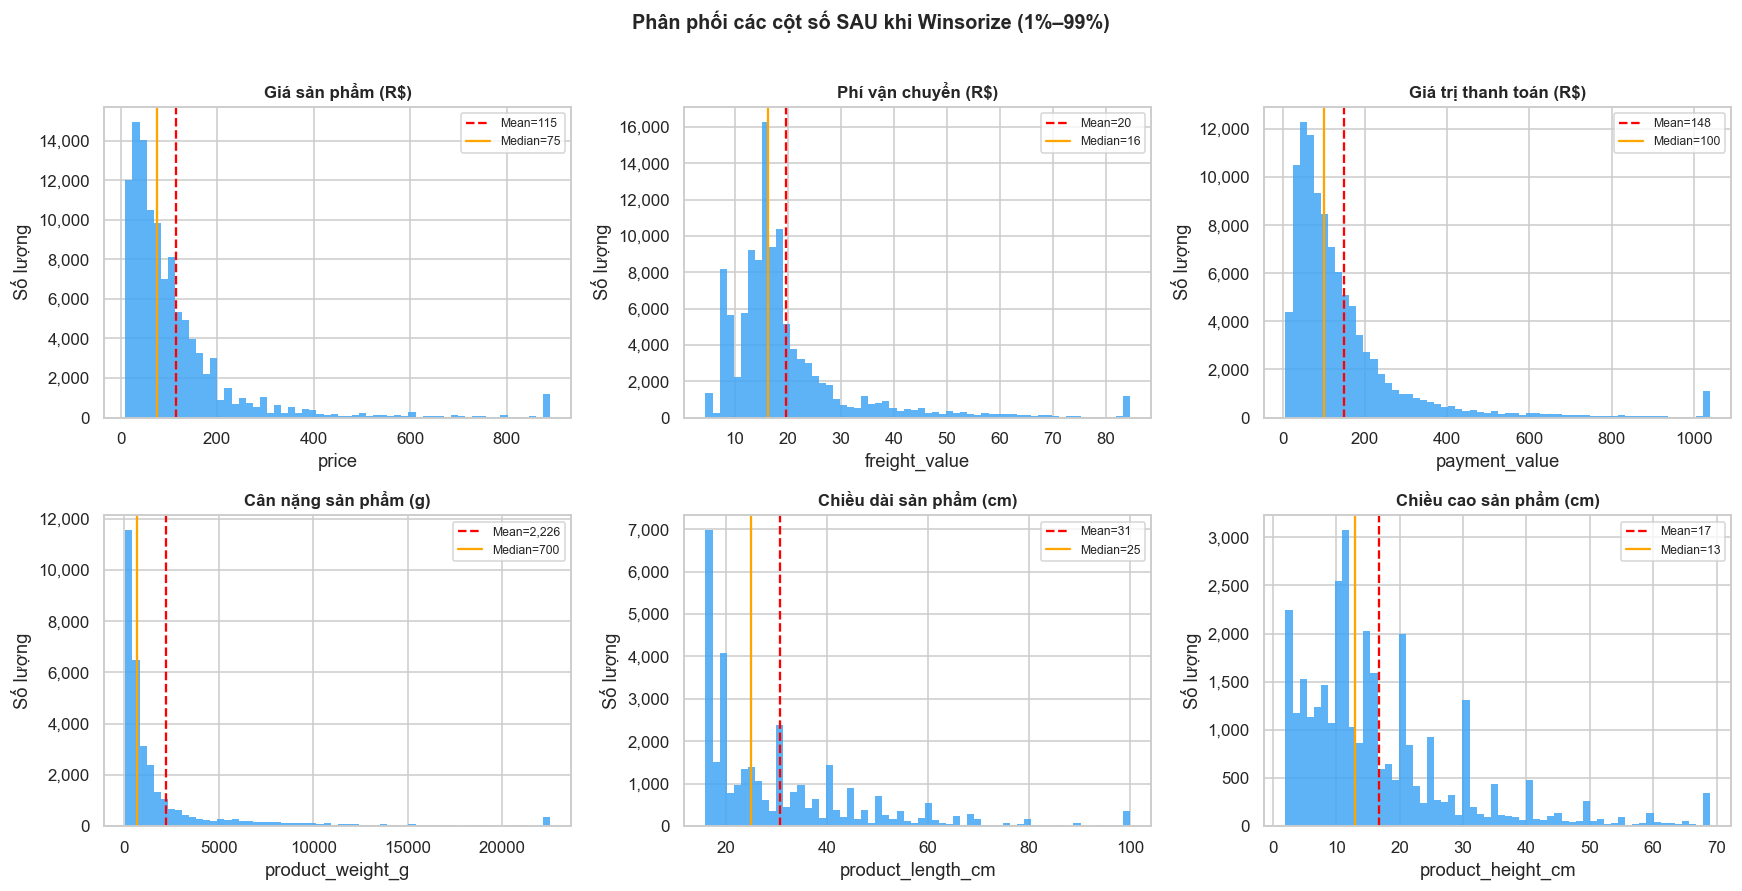

In [13]:
after_configs = [
    (df_order_items,    "price",            "Giá sản phẩm (R$)"),
    (df_order_items,    "freight_value",    "Phí vận chuyển (R$)"),
    (df_order_payments, "payment_value",    "Giá trị thanh toán (R$)"),
    (df_products,       "product_weight_g", "Cân nặng sản phẩm (g)"),
    (df_products,       "product_length_cm","Chiều dài sản phẩm (cm)"),
    (df_products,       "product_height_cm","Chiều cao sản phẩm (cm)"),
]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for i, (df, col, title) in enumerate(after_configs):
    ax = axes[i]
    data = df[col].dropna()
    ax.hist(data, bins=60, color="#42A5F5", edgecolor="none", alpha=0.85)
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Số lượng")
    ax.axvline(data.mean(),   color="red",    linestyle="--", linewidth=1.5, label=f"Mean={data.mean():,.0f}")
    ax.axvline(data.median(), color="orange", linestyle="-",  linewidth=1.5, label=f"Median={data.median():,.0f}")
    ax.legend(fontsize=8)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.suptitle("Phân phối các cột số SAU khi Winsorize (1%–99%)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 6. Feature Engineering

In [14]:
# ── Thời gian ─────────────────────────────────────────────────────────
df_orders["purchase_year"]   = df_orders["order_purchase_timestamp"].dt.year
df_orders["purchase_month"]  = df_orders["order_purchase_timestamp"].dt.month
df_orders["purchase_quarter"]= df_orders["order_purchase_timestamp"].dt.quarter
df_orders["purchase_dow"]    = df_orders["order_purchase_timestamp"].dt.dayofweek  # 0=Mon

# ── Thời gian giao hàng (ngày) ────────────────────────────────────────
df_orders["actual_delivery_days"] = (
    df_orders["order_delivered_customer_date"] -
    df_orders["order_purchase_timestamp"]
).dt.days

df_orders["estimated_delivery_days"] = (
    df_orders["order_estimated_delivery_date"] -
    df_orders["order_purchase_timestamp"]
).dt.days

# ── Giao hàng trễ ─────────────────────────────────────────────────────
df_orders["delay_days"] = (
    df_orders["actual_delivery_days"] - df_orders["estimated_delivery_days"]
)
df_orders["is_late_delivery"] = (df_orders["delay_days"] > 0).astype("Int8")

# ── order_items: tổng giá trị ─────────────────────────────────────────
df_order_items["total_item_value"] = df_order_items["price"] + df_order_items["freight_value"]

print("Feature engineering hoàn tất")
new_feats = ["purchase_year","purchase_month","purchase_quarter","purchase_dow",
             "actual_delivery_days","estimated_delivery_days","delay_days","is_late_delivery"]
display(df_orders[new_feats].describe())

Feature engineering hoàn tất


,purchase_year,purchase_month,purchase_quarter,purchase_dow,actual_delivery_days,estimated_delivery_days,delay_days,is_late_delivery
count,"99,441.00","99,441.00","99,441.00","99,441.00","96,476.00","99,441.00","96,476.00","99,441.00"
mean,"2,017.54",6.03,2.36,2.76,12.09,23.40,-11.28,0.07
std,0.51,3.23,1.06,1.97,9.55,8.83,10.19,0.26
min,"2,016.00",1.00,1.00,0.00,0.00,1.00,-146.00,0.00
25%,"2,017.00",3.00,1.00,1.00,6.00,18.00,-16.00,0.00
50%,"2,018.00",6.00,2.00,3.00,10.00,23.00,-12.00,0.00
75%,"2,018.00",8.00,3.00,4.00,15.00,28.00,-7.00,0.00
max,"2,018.00",12.00,4.00,6.00,209.00,155.00,189.00,1.00


## 7. Xây dựng bảng phân tích tổng hợp

### 7.1 Tổng hợp order_items

In [15]:
items_agg = df_order_items.groupby("order_id").agg(
    total_items         = ("order_item_id",   "count"),
    total_price         = ("price",           "sum"),
    total_freight       = ("freight_value",   "sum"),
    total_order_value   = ("total_item_value","sum"),
    avg_item_price      = ("price",           "mean"),
    unique_sellers      = ("seller_id",       "nunique"),
    has_outlier_price   = ("is_outlier_price","max"),
    has_outlier_freight = ("is_outlier_freight_value","max"),
).reset_index()
print(f"items_agg: {items_agg.shape}")
display(items_agg.head(3))

items_agg: (98666, 9)


,order_id,total_items,total_price,total_freight,total_order_value,avg_item_price,unique_sellers,has_outlier_price,has_outlier_freight
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,72.19,58.90,1,0,0
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,259.83,239.90,1,0,0
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,216.87,199.00,1,0,0


### 7.2 Tổng hợp order_payments

In [16]:
payments_agg = df_order_payments.groupby("order_id").agg(
    total_payment_value  = ("payment_value",        "sum"),
    max_installments     = ("payment_installments", "max"),
    payment_type_count   = ("payment_type",         "nunique"),
    has_outlier_payment  = ("is_outlier_payment_value","max"),
).reset_index()

# Loại thanh toán chính (theo value cao nhất)
primary_pmt = (
    df_order_payments
    .sort_values("payment_value", ascending=False)
    .drop_duplicates(subset=["order_id"])
    [["order_id","payment_type"]]
    .rename(columns={"payment_type":"primary_payment_type"})
)
payments_agg = payments_agg.merge(primary_pmt, on="order_id", how="left")
print(f"payments_agg: {payments_agg.shape}")
display(payments_agg.head(3))

payments_agg: (99440, 6)


,order_id,total_payment_value,max_installments,payment_type_count,has_outlier_payment,primary_payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,0,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,0,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,0,credit_card


### 7.3 Tổng hợp order_reviews

In [17]:
reviews_agg = df_order_reviews.groupby("order_id").agg(
    avg_review_score = ("review_score", "mean"),
    review_count     = ("review_id",    "count"),
    has_comment      = ("review_comment_message",
                        lambda x: int(x.str.len().max() > 0)),
).reset_index()
reviews_agg["avg_review_score"] = reviews_agg["avg_review_score"].round(2)
print(f"reviews_agg: {reviews_agg.shape}")
display(reviews_agg.head(3))

reviews_agg: (98673, 4)


,order_id,avg_review_score,review_count,has_comment
0,00010242fe8c5a6d1ba2dd792cb16214,5.00,1,1
1,00018f77f2f0320c557190d7a144bdd3,4.00,1,0
2,000229ec398224ef6ca0657da4fc703e,5.00,1,1


### 7.4 Join tất cả bảng

In [18]:
# Base: orders (1 dòng = 1 đơn hàng)
df_anal = df_orders.copy()

# Customers
df_anal = df_anal.merge(
    df_customers[["customer_id","customer_unique_id","customer_city","customer_state"]],
    on="customer_id", how="left")

# order_items aggregated
df_anal = df_anal.merge(items_agg,    on="order_id", how="left")
# order_payments aggregated
df_anal = df_anal.merge(payments_agg, on="order_id", how="left")
# order_reviews aggregated
df_anal = df_anal.merge(reviews_agg,  on="order_id", how="left")

# Sản phẩm chính (order_item_id = 1)
first_item = df_order_items[df_order_items["order_item_id"] == 1][
    ["order_id","product_id","seller_id"]
].copy()

# Gắn category tiếng Anh
products_cat = df_products.merge(df_category_trans, on="product_category_name", how="left")
products_cat["product_category_name_english"] = (
    products_cat["product_category_name_english"]
    .fillna(products_cat["product_category_name"])
)
first_item = first_item.merge(
    products_cat[["product_id","product_category_name","product_category_name_english",
                  "product_weight_g","product_length_cm","product_height_cm","product_width_cm"]],
    on="product_id", how="left")
first_item = first_item.merge(
    df_sellers[["seller_id","seller_city","seller_state"]],
    on="seller_id", how="left")

df_anal = df_anal.merge(first_item, on="order_id", how="left")

print(f"Bảng phân tích: {df_anal.shape[0]:,} rows × {df_anal.shape[1]} cols")

Bảng phân tích: 99,441 rows × 45 cols


### 7.5 Hậu xử lý bảng tổng hợp

In [19]:
# --- Review score: điền median cho đơn chưa có review ---
median_score = df_anal["avg_review_score"].median()
df_anal["avg_review_score"].fillna(median_score, inplace=True)

# --- Flag đơn chưa có review ---
df_anal["has_review"] = reviews_agg["order_id"].isin(df_anal["order_id"]).astype(int)

# --- is_late_delivery: chỉ tính được cho đơn đã giao ---
# Các trạng thái khác để NaN, không điền 0 tránh sai lệch
# (xử lý downstream khi cần)

# --- Sắp xếp cột hợp lý ---
front_cols = [
    "order_id","customer_id","customer_unique_id","customer_city","customer_state",
    "order_status","order_purchase_timestamp","order_approved_at",
    "order_delivered_carrier_date","order_delivered_customer_date",
    "order_estimated_delivery_date",
    "purchase_year","purchase_month","purchase_quarter","purchase_dow",
    "actual_delivery_days","estimated_delivery_days","delay_days","is_late_delivery",
    "total_items","total_price","total_freight","total_order_value","avg_item_price",
    "unique_sellers","has_outlier_price","has_outlier_freight",
    "total_payment_value","max_installments","payment_type_count",
    "primary_payment_type","has_outlier_payment",
    "avg_review_score","review_count","has_comment","has_review",
    "product_id","product_category_name","product_category_name_english",
    "product_weight_g","product_length_cm","product_height_cm","product_width_cm",
    "seller_id","seller_city","seller_state",
]
# Chỉ giữ cột tồn tại thực sự
front_cols = [c for c in front_cols if c in df_anal.columns]
other_cols = [c for c in df_anal.columns if c not in front_cols]
df_anal = df_anal[front_cols + other_cols]

print("Bảng tổng hợp hoàn chỉnh!")
print(f"   {df_anal.shape[0]:,} rows × {df_anal.shape[1]} cols")
display(df_anal.head(3))

Bảng tổng hợp hoàn chỉnh!
   99,441 rows × 46 cols


,order_id,customer_id,customer_unique_id,customer_city,customer_state,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,purchase_year,purchase_month,purchase_quarter,purchase_dow,actual_delivery_days,estimated_delivery_days,delay_days,is_late_delivery,total_items,total_price,total_freight,total_order_value,avg_item_price,unique_sellers,has_outlier_price,has_outlier_freight,total_payment_value,max_installments,payment_type_count,primary_payment_type,has_outlier_payment,avg_review_score,review_count,has_comment,has_review,product_id,product_category_name,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_id,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017,10,4,0,8.00,15,-7.00,0,1.00,29.99,8.72,38.71,29.99,1.00,0.00,0.00,43.40,1.00,2.00,voucher,1.00,4.00,1.00,1.00,1.00,87285b34884572647811a353c7ac498a,utilidades_domesticas,housewares,500.00,19.00,8.00,13.00,3504c0cb71d7fa48d967e0e4c94d59d9,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,barreiras,BA,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018,7,3,1,13.00,19,-6.00,0,1.00,118.70,22.76,141.46,118.70,1.00,0.00,0.00,141.46,1.00,1.00,boleto,0.00,4.00,1.00,1.00,1.00,595fac2a385ac33a80bd5114aec74eb8,perfumaria,perfumery,400.00,19.00,13.00,19.00,289cdb325fb7e7f891c38608bf9e0962,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018,8,3,2,9.00,26,-17.00,0,1.00,159.90,19.22,179.12,159.90,1.00,0.00,0.00,179.12,3.00,1.00,credit_card,0.00,5.00,1.00,0.00,1.00,aa4383b373c6aca5d8797843e5594415,automotivo,auto,420.00,24.00,19.00,21.00,4869f7a5dfa277a7dca6462dcf3b52b2,guariba,SP


## 8. Kiểm tra bảng tổng hợp & Quick EDA

### 8.1 Missing values bảng tổng hợp

In [20]:
miss  = df_anal.isnull().sum()
pct   = (miss / len(df_anal) * 100).round(2)
miss_df = pd.DataFrame({"Missing": miss, "Pct (%)": pct})
miss_df = miss_df[miss_df["Missing"] > 0].sort_values("Pct (%)", ascending=False)
print(f"Cột còn missing sau khi join ({len(miss_df)} cột):")
display(miss_df)

Cột còn missing sau khi join (31 cột):


,Missing,Pct (%)
order_delivered_customer_date,2965,2.98
actual_delivery_days,2965,2.98
delay_days,2965,2.98
order_delivered_carrier_date,1783,1.79
seller_state,775,0.78
seller_city,775,0.78
product_category_name_english,775,0.78
product_category_name,775,0.78
product_id,775,0.78
product_height_cm,775,0.78


### 8.2 Thống kê mô tả các cột số chính

In [21]:
key_cols = [
    "total_price","total_freight","total_order_value","avg_item_price",
    "total_payment_value","max_installments",
    "actual_delivery_days","delay_days","avg_review_score"
]
display(df_anal[key_cols].describe().T.round(2))

,count,mean,std,min,25%,50%,75%,max
total_price,"98,666.00",131.64,159.21,9.99,45.90,86.90,149.90,"7,120.00"
total_freight,"98,666.00",22.42,18.11,4.42,13.85,17.18,24.06,626.64
total_order_value,"98,666.00",154.06,168.38,17.38,62.00,105.30,176.86,"7,344.08"
avg_item_price,"98,666.00",120.00,140.65,9.99,41.99,79.00,139.90,890.00
total_payment_value,"99,440.00",154.63,165.57,6.69,62.01,105.37,176.99,"2,079.83"
max_installments,"99,440.00",2.93,2.72,0.00,1.00,2.00,4.00,24.00
actual_delivery_days,"96,476.00",12.09,9.55,0.00,6.00,10.00,15.00,209.00
delay_days,"96,476.00",-11.28,10.19,-146.00,-16.00,-12.00,-7.00,189.00
avg_review_score,"99,441.00",4.09,1.34,1.00,4.00,5.00,5.00,5.00


### 8.3 Quick visualization

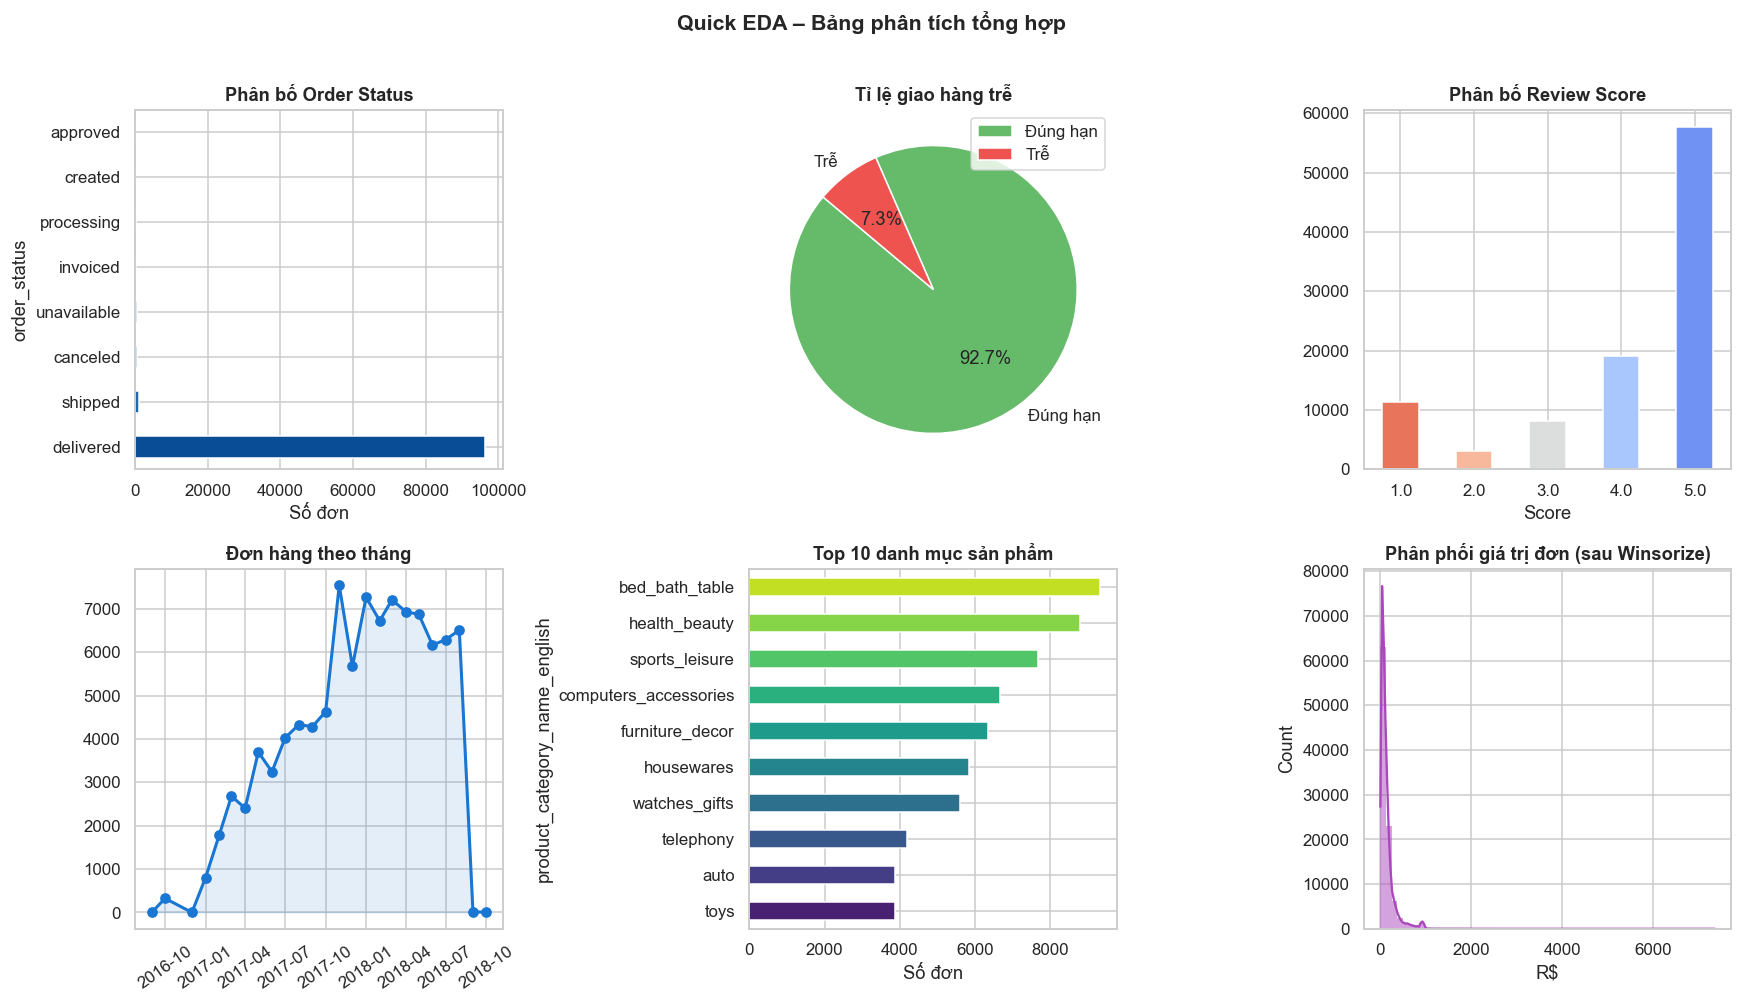

In [22]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# 1. Order status
ax = axes[0][0]
vc = df_anal["order_status"].value_counts()
vc.plot(kind="barh", ax=ax, color=sns.color_palette("Blues_r", len(vc)))
ax.set_title("Phân bố Order Status", fontweight="bold")
ax.set_xlabel("Số đơn")

# 2. Tỉ lệ giao hàng trễ
ax = axes[0][1]
late = df_anal["is_late_delivery"].value_counts().rename({0:"Đúng hạn",1:"Trễ"})
late.plot(kind="pie", ax=ax, autopct="%1.1f%%",
          colors=["#66BB6A","#EF5350"], startangle=140, legend=True)
ax.set_title("Tỉ lệ giao hàng trễ", fontweight="bold")
ax.set_ylabel("")

# 3. Review score
ax = axes[0][2]
df_anal["avg_review_score"].round().value_counts().sort_index().plot(
    kind="bar", ax=ax, color=sns.color_palette("coolwarm_r",5))
ax.set_title("Phân bố Review Score", fontweight="bold")
ax.set_xlabel("Score")
ax.tick_params(axis="x", rotation=0)

# 4. Đơn hàng theo tháng
ax = axes[1][0]
monthly = (df_anal.dropna(subset=["purchase_year","purchase_month"])
           .groupby(["purchase_year","purchase_month"]).size().reset_index(name="n"))
monthly["period"] = pd.to_datetime(
    monthly["purchase_year"].astype(str)+"-"+monthly["purchase_month"].astype(str).str.zfill(2))
monthly = monthly.sort_values("period")
ax.plot(monthly["period"], monthly["n"], marker="o", linewidth=2, color="#1976D2")
ax.fill_between(monthly["period"], monthly["n"], alpha=0.12, color="#1976D2")
ax.set_title("Đơn hàng theo tháng", fontweight="bold")
ax.tick_params(axis="x", rotation=35)

# 5. Top 10 product category
ax = axes[1][1]
top_cat = df_anal["product_category_name_english"].value_counts().head(10)
top_cat[::-1].plot(kind="barh", ax=ax, color=sns.color_palette("viridis", 10))
ax.set_title("Top 10 danh mục sản phẩm", fontweight="bold")
ax.set_xlabel("Số đơn")

# 6. Tổng giá trị đơn hàng distribution
ax = axes[1][2]
sns.histplot(df_anal["total_order_value"].dropna(), bins=60, ax=ax,
             color="#AB47BC", edgecolor="none", kde=True)
ax.set_title("Phân phối giá trị đơn (sau Winsorize)", fontweight="bold")
ax.set_xlabel("R$")

plt.suptitle("Quick EDA – Bảng phân tích tổng hợp", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 9. Lưu output cho các bước tiếp theo

> File `olist_analytical_table.csv` là **input duy nhất** cho:
> - **Bước 3** – Data Analysis with SQL (load vào SQLite / DuckDB)
> - **Bước 4** – Data Analysis with Python (pandas, scipy)
> - **Bước 5** – Data Visualization (matplotlib, seaborn, plotly)
> - **Bước 6** – Regression / ML Analysis (scikit-learn)

In [23]:
OUTPUT = "olist_analytical_table.csv"
df_anal.to_csv(OUTPUT, index=False)

print("=" * 55)
print(f"Đã lưu: '{OUTPUT}'")
print(f"   Rows   : {df_anal.shape[0]:,}")
print(f"   Cols   : {df_anal.shape[1]}")
print("=" * 55)
print("\nDanh sách cột đầy đủ:")
for i, col in enumerate(df_anal.columns, 1):
    dtype = str(df_anal[col].dtype)
    print(f"  {i:3d}. {col:<45s} [{dtype}]")

Đã lưu: 'olist_analytical_table.csv'
   Rows   : 99,441
   Cols   : 46

Danh sách cột đầy đủ:
    1. order_id                                      [object]
    2. customer_id                                   [object]
    3. customer_unique_id                            [object]
    4. customer_city                                 [object]
    5. customer_state                                [object]
    6. order_status                                  [object]
    7. order_purchase_timestamp                      [datetime64[ns]]
    8. order_approved_at                             [datetime64[ns]]
    9. order_delivered_carrier_date                  [datetime64[ns]]
   10. order_delivered_customer_date                 [datetime64[ns]]
   11. order_estimated_delivery_date                 [datetime64[ns]]
   12. purchase_year                                 [int32]
   13. purchase_month                                [int32]
   14. purchase_quarter                              [int32]
 

## 10. Tóm tắt pipeline

```
RAW DATA (8 CSV)
      │
      ▼
[Bước 2 – Notebook này]
  ├─ 1. Data Loading
  ├─ 2. Data Understanding (ER diagram, preview)
  ├─ 3. Quality Check (missing / duplicate / referential integrity)
  ├─ 4. Preprocessing (datetime, string, missing values)
  ├─ 5. Outlier Detection & Winsorization (1%–99% cap)
  │       └─ is_outlier_* flags giữ lại để phân tích
  ├─ 6. Feature Engineering (delay_days, is_late_delivery, ...)
  ├─ 7. Build Analytical Table (join 8 bảng → 1 bảng)
  ├─ 8. Final QA + Quick EDA
  └─ 9. Export → olist_analytical_table.csv
              │
    ┌─────────┼─────────┬──────────────┐
    ▼         ▼         ▼              ▼
 Bước 3    Bước 4    Bước 5         Bước 6
  SQL      Python      Viz         Regression
```
